# GRÁFICAS PERCENTILES - MTBF

Primero se revisa los datos de los percentiles y MBTF durante todo el tiempo

In [1]:
import os
import json
import pandas as pd

ruta = "/home/cesga/tec_sis6/tfm/logs"
registros = []

for archivo in os.listdir(ruta):
    if archivo.startswith("fichero_resultados_") and archivo.endswith(".json"):
        with open(os.path.join(ruta, archivo), 'r') as f:
            contenido = json.load(f)
            for fecha, hosts in contenido.items():
                for host, percentiles in hosts.items():
                    for p, valores in percentiles.items():
                        registros.append({
                            'fecha': fecha,
                            'host': host,
                            'percentil': p,
                            'count_before': valores['count_before'],
                            'count_after': valores['count_after'],
                            'mtbf': valores['mbtf']
                        })

df = pd.DataFrame(registros)

percentil_map = {
    'percentil_0': '25%',
    'percentil_1': '50%',
    'percentil_2': '75%',
    'percentil_3': '90%',
    'nopercetil': 'N/A'
}

df['percentil'] = df['percentil'].map(percentil_map)
df['fecha'] = pd.to_datetime(df['fecha'], format='%Y%m')

In [2]:
print(df)

     count_after  count_before      fecha     host           mtbf percentil
0              6            18 2021-12-01  c202-38   65915.800000       75%
1              3            18 2021-12-01  c202-38            NaN       90%
2             13            18 2021-12-01  c202-38   27836.000000       25%
3              9            18 2021-12-01  c202-38   41515.375000       50%
4              0             0 2021-12-01  c204-19       0.000000       N/A
5              3             9 2021-12-01  c211-22            NaN       75%
6              3             9 2021-12-01  c211-22            NaN       90%
7              3             9 2021-12-01  c211-22            NaN       25%
8              3             9 2021-12-01  c211-22            NaN       50%
9             10            40 2021-12-01  c211-21    3981.111111       75%
10             5            40 2021-12-01  c211-21    8957.500000       90%
11            14            40 2021-12-01  c211-21    2756.153846       25%
12          

Se puede ver la gráfica de todos los hosts, vemos la fecha contra el MTBF. Cada percentil en una gráfica separada. 

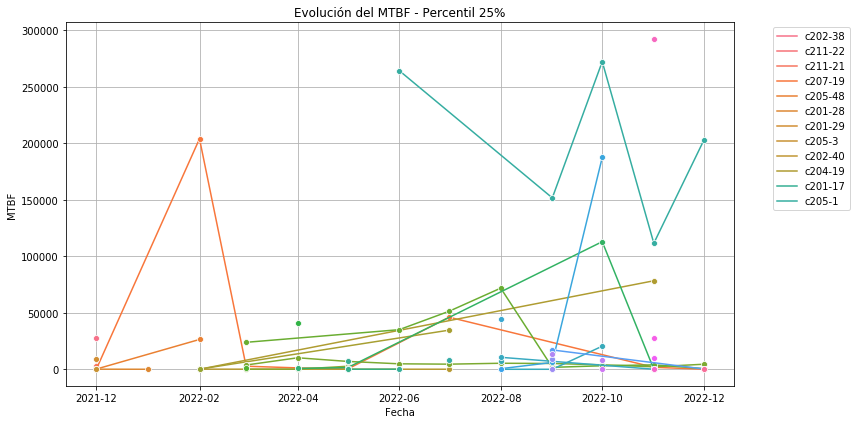

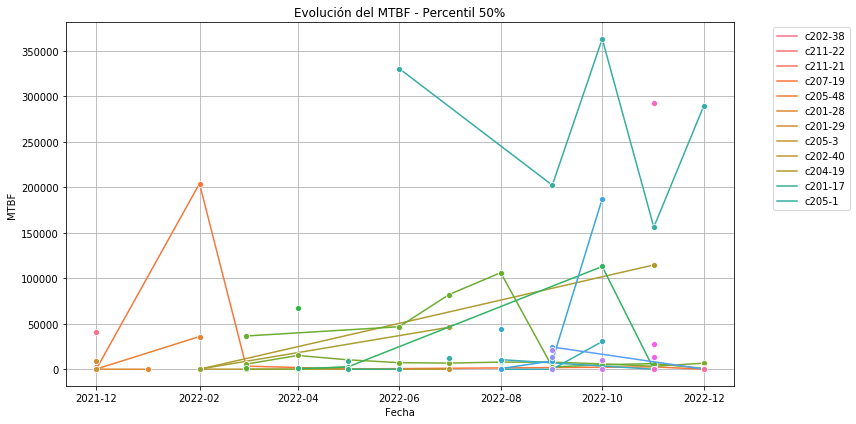

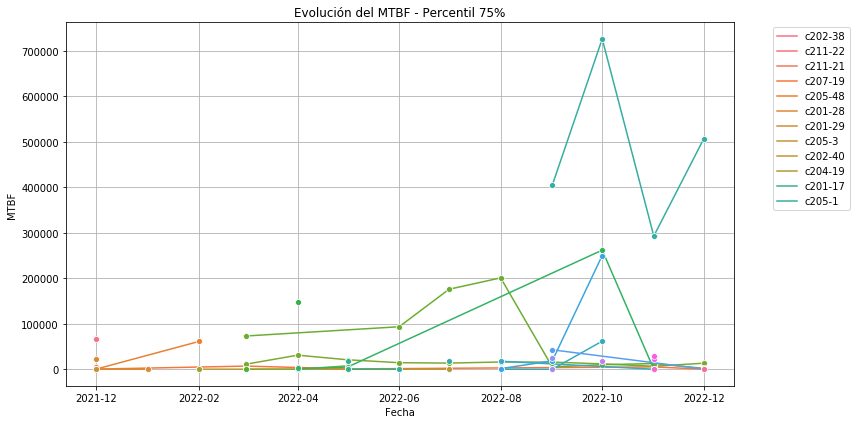

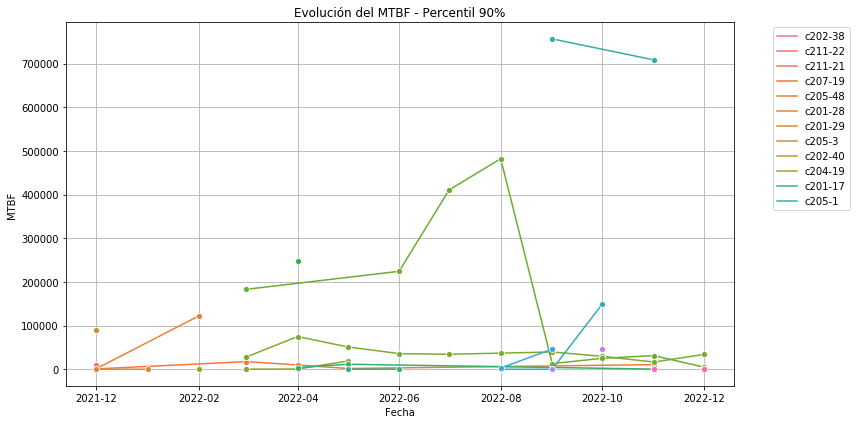

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

percentiles = ['25%', '50%', '75%', '90%']
hosts_en_leyenda = [u'c202-38', u'c201-28', u'c205-48', u'c201-29', u'c205-3', u'c205-1', 
                    u'c207-19', u'c211-22', u'c204-19', u'c211-21', u'c201-17', u'c202-40', u'...'] 

for p in percentiles:
    df_p = df[df['percentil'] == p]
    
    plt.figure(figsize=(12, 6))
    ax = sns.lineplot(data=df_p, x='fecha', y='mtbf', hue='host', marker='o')

    # Filtrar la leyenda para que solo incluya ciertos hosts
    handles, labels = ax.get_legend_handles_labels()
    nueva_leyenda = [(h, l) for h, l in zip(handles, labels) if l in hosts_en_leyenda]
    if nueva_leyenda:
        new_handles, new_labels = zip(*nueva_leyenda)
        ax.legend(new_handles, new_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.legend([], [], frameon=False)

    plt.title(u'Evolución del MTBF - Percentil {}'.format(p))
    plt.xlabel(u'Fecha')
    plt.ylabel(u'MTBF')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [4]:
df_spark = spark.createDataFrame(df)

In [5]:
df_spark.filter("host='c205-1'").show(100, truncate=False)

+-----------+------------+-------------------+------+------------------+---------+
|count_after|count_before|fecha              |host  |mtbf              |percentil|
+-----------+------------+-------------------+------+------------------+---------+
|0          |0           |2021-12-01 00:00:00|c205-1|0.0               |N/A      |
|0          |0           |2022-02-01 00:00:00|c205-1|0.0               |N/A      |
|0          |0           |2022-04-01 00:00:00|c205-1|0.0               |N/A      |
|0          |0           |2022-05-01 00:00:00|c205-1|0.0               |N/A      |
|3          |8           |2022-06-01 00:00:00|c205-1|NaN               |75%      |
|2          |8           |2022-06-01 00:00:00|c205-1|NaN               |90%      |
|6          |8           |2022-06-01 00:00:00|c205-1|264397.0          |25%      |
|5          |8           |2022-06-01 00:00:00|c205-1|330496.25         |50%      |
|0          |0           |2022-07-01 00:00:00|c205-1|0.0               |N/A      |
|0  

In [7]:
df_spark.show()

+-----------+------------+-------------------+-------+------------------+---------+
|count_after|count_before|              fecha|   host|              mtbf|percentil|
+-----------+------------+-------------------+-------+------------------+---------+
|          6|          18|2021-12-01 00:00:00|c202-38|           65915.8|      75%|
|          3|          18|2021-12-01 00:00:00|c202-38|               NaN|      90%|
|         13|          18|2021-12-01 00:00:00|c202-38|           27836.0|      25%|
|          9|          18|2021-12-01 00:00:00|c202-38|         41515.375|      50%|
|          0|           0|2021-12-01 00:00:00|c204-19|               0.0|      N/A|
|          3|           9|2021-12-01 00:00:00|c211-22|               NaN|      75%|
|          3|           9|2021-12-01 00:00:00|c211-22|               NaN|      90%|
|          3|           9|2021-12-01 00:00:00|c211-22|               NaN|      25%|
|          3|           9|2021-12-01 00:00:00|c211-22|               NaN|   

In [8]:
df_spark.filter("host='c208-19'").show()

+-----------+------------+-------------------+-------+------------------+---------+
|count_after|count_before|              fecha|   host|              mtbf|percentil|
+-----------+------------+-------------------+-------+------------------+---------+
|        103|         402|2022-03-01 00:00:00|c208-19|11189.470588235294|      75%|
|         42|         402|2022-03-01 00:00:00|c208-19|27837.219512195123|      90%|
|        304|         402|2022-03-01 00:00:00|c208-19|  3767.13201320132|      25%|
|        203|         402|2022-03-01 00:00:00|c208-19|  5650.69801980198|      50%|
|         23|          91|2022-04-01 00:00:00|c208-19|31021.954545454544|      75%|
|         10|          91|2022-04-01 00:00:00|c208-19| 75010.33333333333|      90%|
|         68|          91|2022-04-01 00:00:00|c208-19|10186.313432835821|      25%|
|         46|          91|2022-04-01 00:00:00|c208-19|15166.288888888888|      50%|
|        117|         465|2022-05-01 00:00:00|c208-19|20899.025862068964|   

In [10]:
from pyspark.sql.functions import *

(df_spark
 .withColumn("fecha", date_format(to_date("fecha"), "yyyyMM"))
 .groupBy("host", "percentil")
 .agg(collect_list("fecha").alias("fechas"))
 .withColumn("size_fechas", size("fechas"))
 .orderBy(desc("size_fechas"))
 .show())

+-------+---------+--------------------+-----------+
|   host|percentil|              fechas|size_fechas|
+-------+---------+--------------------+-----------+
|c208-19|      25%|[202203, 202204, ...|         10|
|c208-19|      90%|[202212, 202208, ...|         10|
|c208-19|      75%|[202212, 202208, ...|         10|
|c208-19|      50%|[202212, 202208, ...|         10|
|c211-10|      50%|[202212, 202208, ...|          8|
|c211-10|      90%|[202212, 202208, ...|          8|
|c207-19|      50%|[202212, 202211, ...|          8|
|c211-10|      75%|[202212, 202208, ...|          8|
|c207-19|      90%|[202112, 202202, ...|          8|
|c207-19|      25%|[202112, 202202, ...|          8|
|c207-19|      75%|[202112, 202202, ...|          8|
|c211-10|      25%|[202212, 202208, ...|          8|
| c205-1|      N/A|[202208, 202112, ...|          6|
| c205-1|      50%|[202212, 202209, ...|          5|
| c205-1|      90%|[202206, 202212, ...|          5|
| c205-1|      75%|[202206, 202212, ...|      

Veamos los hosts c208-19, c211-10, c207-19, c205-1:

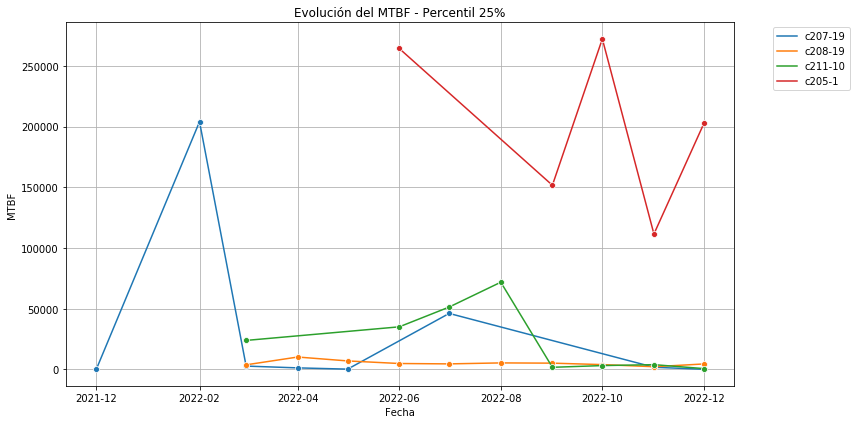

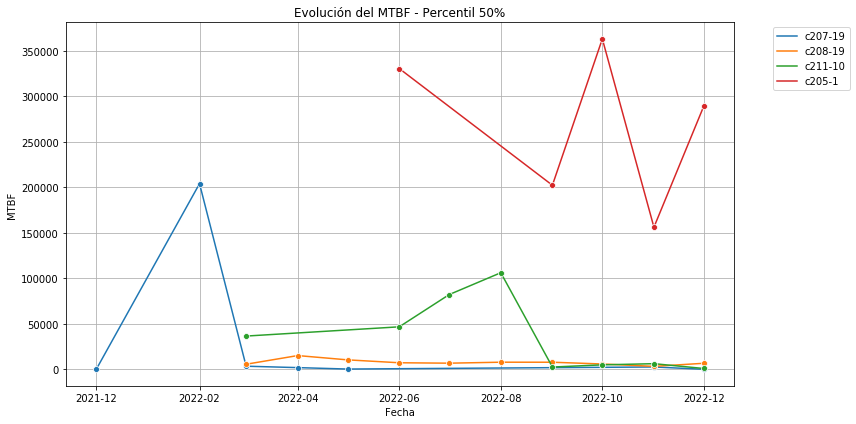

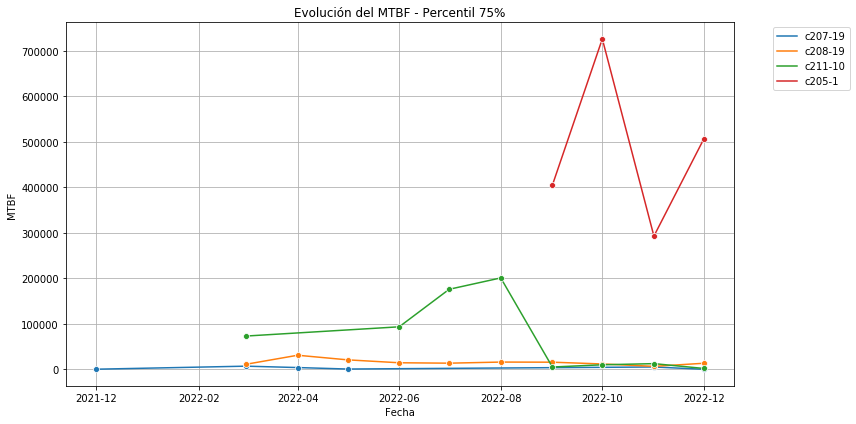

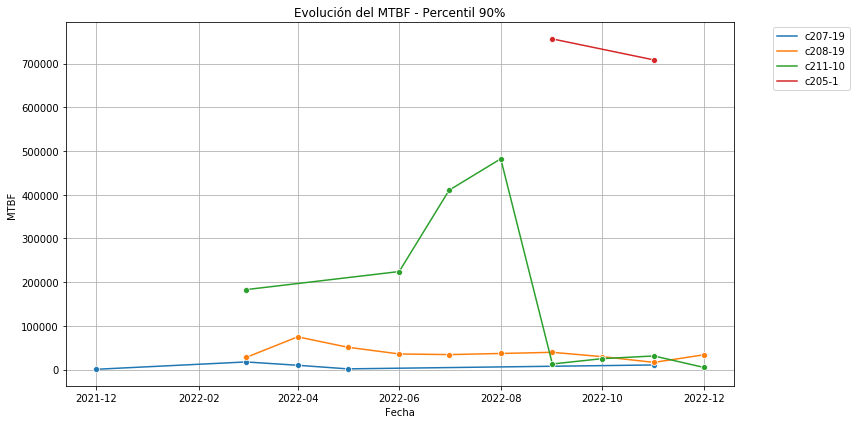

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

percentiles = ['25%', '50%', '75%', '90%']
hosts_en_leyenda = ["c208-19","c211-10", "c207-19", "c205-1"] 

for p in percentiles:
    df_p = df[(df['percentil'] == p) & (df['host'].isin(["c208-19","c211-10", "c207-19", "c205-1"]))]
    
    plt.figure(figsize=(12, 6))
    ax = sns.lineplot(data=df_p, x='fecha', y='mtbf', hue='host', marker='o')

    # Filtrar la leyenda para que solo incluya ciertos hosts
    handles, labels = ax.get_legend_handles_labels()
    nueva_leyenda = [(h, l) for h, l in zip(handles, labels) if l in hosts_en_leyenda]
    if nueva_leyenda:
        new_handles, new_labels = zip(*nueva_leyenda)
        ax.legend(new_handles, new_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.legend([], [], frameon=False)

    plt.title(u'Evolución del MTBF - Percentil {}'.format(p))
    plt.xlabel(u'Fecha')
    plt.ylabel(u'MTBF')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Veamos el host c208-19:

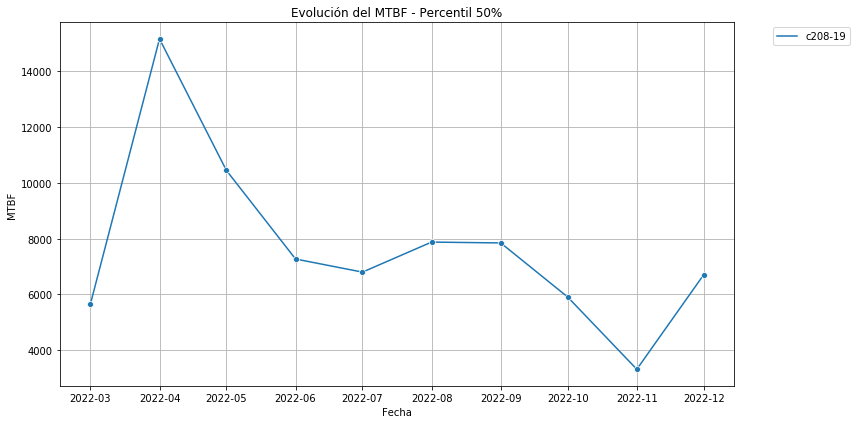

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

percentiles = ['50%']
hosts_en_leyenda = ["c208-19"]

for p in percentiles:
    df_p = df[(df['percentil'] == p) & (df['host'].isin(["c208-19"]))]
    
    plt.figure(figsize=(12, 6))
    ax = sns.lineplot(data=df_p, x='fecha', y='mtbf', hue='host', marker='o')

    # Filtrar la leyenda para que solo incluya ciertos hosts
    handles, labels = ax.get_legend_handles_labels()
    nueva_leyenda = [(h, l) for h, l in zip(handles, labels) if l in hosts_en_leyenda]
    if nueva_leyenda:
        new_handles, new_labels = zip(*nueva_leyenda)
        ax.legend(new_handles, new_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.legend([], [], frameon=False)

    plt.title(u'Evolución del MTBF - Percentil {}'.format(p))
    plt.xlabel(u'Fecha')
    plt.ylabel(u'MTBF')
    plt.grid(True)
    plt.tight_layout()
    plt.show()